# Local Training — 15-Class Medical Action Recognition

**Machine:** RTX 5090 (34 GB VRAM) &bull; Python 3.10 &bull; PyTorch 2.11+cu128

All training runs in-notebook so outputs are preserved. Covers:
1. **Centralized baselines** (2D COCO-17, 3D NTU-25)
2. **Federated learning** (FedAvg, FedBN, FedProx)
3. **Analysis** (learning curves, confusion matrices, per-class accuracy)
4. **Experiment log** (auto-append to `experiments/log.md`)

In [2]:
# ── Setup & GPU check ──
import sys, os, time, json, math, csv
from pathlib import Path
from collections import Counter
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Ensure demo1_fed_skeleton is on path
ROOT = Path(os.getcwd())
if ROOT.name != 'pyskl-research':
    ROOT = ROOT.parent  # handle notebook cwd quirks
DEMO_DIR = ROOT / 'demo1_fed_skeleton'
sys.path.insert(0, str(DEMO_DIR))

from models.stgcn import build_model, count_parameters
from prepare_medical_data import MEDICAL_LABELS, NUM_CLASSES

OUTPUT_DIR = DEMO_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU:    {torch.cuda.get_device_name()}")
    props = torch.cuda.get_device_properties(0)
    vram = getattr(props, 'total_mem', None) or getattr(props, 'total_memory', 0)
    print(f"VRAM:   {vram / 1e9:.1f} GB")
print(f"PyTorch: {torch.__version__}")
print(f"Classes: {NUM_CLASSES}")
for i, name in enumerate(MEDICAL_LABELS):
    print(f"  [{i:2d}] {name}")

Microsoft Visual C++ Redistributable is not installed, this may lead to the DLL load failure.
It can be downloaded at https://aka.ms/vs/17/release/vc_redist.x64.exe
Device: cuda
GPU:    NVIDIA GeForce RTX 5090
VRAM:   34.2 GB
PyTorch: 2.11.0+cu128
Classes: 15
  [ 0] falling
  [ 1] staggering
  [ 2] nausea/vomiting
  [ 3] touch head
  [ 4] touch chest
  [ 5] touch back
  [ 6] touch neck
  [ 7] sneeze/cough
  [ 8] standing up
  [ 9] sitting down
  [10] walking towards
  [11] walking apart
  [12] drinking
  [13] eating
  [14] phone call


In [3]:
# ── Reproducibility ──
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = False  # faster
    torch.backends.cudnn.benchmark = True
print(f"Seed: {SEED}")

Seed: 42


In [4]:
# ── Helper functions ──

def load_result(tag):
    """Load a saved results JSON."""
    with open(OUTPUT_DIR / f'{tag}_results.json') as f:
        return json.load(f)


def load_data(data_dir, batch_size=128):
    """Load train/test NPZ into DataLoaders."""
    data_dir = Path(data_dir)
    tr = np.load(data_dir / 'train.npz')
    te = np.load(data_dir / 'test.npz')
    x_train = torch.from_numpy(tr['x'].astype(np.float32))
    y_train = torch.from_numpy(tr['y'].astype(np.int64))
    x_test  = torch.from_numpy(te['x'].astype(np.float32))
    y_test  = torch.from_numpy(te['y'].astype(np.int64))
    print(f"Train: {x_train.shape} ({len(y_train)} samples)")
    print(f"Test:  {x_test.shape}  ({len(y_test)} samples)")
    train_loader = DataLoader(TensorDataset(x_train, y_train),
                              batch_size=batch_size, shuffle=True, drop_last=True)
    test_loader  = DataLoader(TensorDataset(x_test, y_test),
                              batch_size=batch_size, shuffle=False)
    return train_loader, test_loader


def get_cosine_lr(epoch, total_epochs, base_lr, warmup_epochs=5, min_lr=1e-5):
    if epoch < warmup_epochs:
        return base_lr * (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
    return min_lr + 0.5 * (base_lr - min_lr) * (1 + math.cos(math.pi * progress))


def train_one_epoch(model, loader, optimizer, criterion, device,
                    epoch, total_epochs, base_lr, warmup_epochs):
    lr = get_cosine_lr(epoch, total_epochs, base_lr, warmup_epochs)
    for pg in optimizer.param_groups:
        pg['lr'] = lr
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        loss_sum += loss.item() * yb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += yb.size(0)
    return loss_sum / total, correct / total, lr


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss_sum += criterion(logits, yb).item() * yb.size(0)
        preds = logits.argmax(1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(yb.cpu().tolist())
    return loss_sum / total, correct / total, all_preds, all_labels


def compute_metrics(preds, labels, num_classes):
    """Per-class accuracy + confusion matrix."""
    cm = np.zeros((num_classes, num_classes), dtype=int)
    cc, ct = Counter(), Counter()
    for p, l in zip(preds, labels):
        cm[l][p] += 1
        ct[l] += 1
        if p == l:
            cc[l] += 1
    per_class = {}
    for c in range(num_classes):
        name = MEDICAL_LABELS[c] if c < len(MEDICAL_LABELS) else f'class_{c}'
        per_class[c] = {
            'name': name,
            'accuracy': round(cc[c] / max(ct[c], 1), 4),
            'correct': cc[c],
            'total': ct[c],
        }
    return per_class, cm


def print_per_class(per_class):
    print(f"{'Class':2s}  {'Name':20s}  {'Acc':>7s}  {'Correct':>7s}")
    print('-' * 45)
    for c in sorted(per_class.keys()):
        info = per_class[c]
        print(f"[{c:2d}]  {info['name']:20s}  {info['accuracy']:.4f}  "
              f"{info['correct']:>4d}/{info['total']:<4d}")


def save_confusion_csv(cm, label_names, path):
    with open(path, 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow([''] + label_names)
        for i, row in enumerate(cm):
            w.writerow([label_names[i]] + row.tolist())
    print(f"Confusion matrix saved: {path}")

print("Helpers loaded.")

Helpers loaded.


In [4]:
# ── Centralized training function ──

def train_centralized(tag, data_dir, graph, num_classes=15,
                      epochs=80, batch_size=128, lr=0.05,
                      warmup=5, dropout=0.3, patience=0):
    """Full centralized training run. Returns results dict."""
    print(f"\n{'='*60}")
    print(f"  Starting: {tag}")
    print(f"  graph={graph}  epochs={epochs}  lr={lr}  patience={patience}")
    print(f"{'='*60}\n")

    train_loader, test_loader = load_data(data_dir, batch_size)

    model = build_model(
        num_classes=num_classes, in_channels=3, base_channels=64,
        num_stages=6, num_person=2, dropout=dropout, graph=graph,
    ).to(device)
    print(f"Model params: {count_parameters(model):,}")

    optimizer = torch.optim.SGD(
        model.parameters(), lr=lr,
        momentum=0.9, weight_decay=1e-4, nesterov=True)
    criterion = nn.CrossEntropyLoss()

    best_acc, best_epoch = 0.0, 0
    no_improve = 0
    history = []
    t_start = time.time()

    for epoch in range(epochs):
        t0 = time.time()
        tr_loss, tr_acc, cur_lr = train_one_epoch(
            model, train_loader, optimizer, criterion, device,
            epoch, epochs, lr, warmup)
        te_loss, te_acc, _, _ = evaluate(model, test_loader, criterion, device)
        dt = time.time() - t0

        is_best = te_acc > best_acc
        if is_best:
            best_acc = te_acc
            best_epoch = epoch + 1
            no_improve = 0
            torch.save(model.state_dict(), OUTPUT_DIR / f'{tag}_best.pt')
        else:
            no_improve += 1

        history.append({
            'epoch': epoch + 1, 'lr': round(cur_lr, 6),
            'train_loss': round(tr_loss, 4), 'train_acc': round(tr_acc, 4),
            'test_loss': round(te_loss, 4), 'test_acc': round(te_acc, 4),
            'best_acc': round(best_acc, 4), 'time_s': round(dt, 1),
        })

        star = ' *' if is_best else ''
        print(f"E{epoch+1:3d}/{epochs}  lr={cur_lr:.5f}  "
              f"tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f}  "
              f"te_loss={te_loss:.4f} te_acc={te_acc:.4f}{star}  {dt:.1f}s")

        if (epoch + 1) % 10 == 0:
            torch.save(model.state_dict(), OUTPUT_DIR / f'{tag}_e{epoch+1}.pt')

        # Early stopping
        if patience > 0 and (epoch + 1) > warmup and no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch+1} "
                  f"(no improvement for {patience} epochs)")
            break

    total_time = time.time() - t_start
    actual_epochs = epoch + 1

    # Final eval with per-class metrics (using best model)
    model.load_state_dict(torch.load(OUTPUT_DIR / f'{tag}_best.pt',
                                     map_location=device, weights_only=True))
    _, final_acc, preds, labels = evaluate(model, test_loader, criterion, device)
    per_class, cm = compute_metrics(preds, labels, num_classes)

    # Save
    torch.save(model.state_dict(), OUTPUT_DIR / f'{tag}_final.pt')
    save_confusion_csv(cm, MEDICAL_LABELS[:num_classes],
                       OUTPUT_DIR / f'{tag}_confusion_matrix.csv')

    result = {
        'tag': tag, 'graph': graph, 'num_classes': num_classes,
        'epochs': actual_epochs, 'max_epochs': epochs,
        'patience': patience, 'stopped_early': actual_epochs < epochs,
        'batch_size': batch_size, 'lr': lr,
        'weight_decay': 1e-4, 'warmup_epochs': warmup,
        'dropout': dropout, 'base_channels': 64,
        'num_stages': 6, 'num_person': 2,
        'best_acc': best_acc, 'best_epoch': best_epoch,
        'final_acc': final_acc, 'total_time_s': round(total_time, 1),
        'params': count_parameters(model),
        'label_names': MEDICAL_LABELS[:num_classes],
        'per_class_acc': {int(k): v for k, v in per_class.items()},
        'confusion_matrix': cm.tolist(),
        'history': history,
    }
    with open(OUTPUT_DIR / f'{tag}_results.json', 'w') as f:
        json.dump(result, f, indent=2)

    print(f"\n{'='*60}")
    print(f"  {tag} COMPLETE")
    print(f"  Best: {best_acc:.4f} (epoch {best_epoch}) | Final: {final_acc:.4f}")
    print(f"  Time: {total_time/60:.1f} min ({actual_epochs} epochs)")
    print(f"{'='*60}")
    print_per_class(per_class)

    return result

print("train_centralized() ready.")

train_centralized() ready.


---
## 1. Centralized 2D Baseline (COCO-17 joints)
**Already trained** — best 90.57% at epoch 46. Loading saved results.

In [5]:
# ── Load 2D centralized results (already trained) ──
results_2d = load_result('cent_2d_15cls')
print(f"2D Centralized: best_acc={results_2d['best_acc']:.4f} "
      f"(epoch {results_2d['best_epoch']}) | "
      f"final_acc={results_2d['final_acc']:.4f} | "
      f"time={results_2d['total_time_s']/60:.1f} min | "
      f"params={results_2d['params']:,}")
print("\nPer-class accuracy:")
for c, info in sorted(results_2d['per_class_acc'].items(), key=lambda x: int(x[0])):
    print(f"  [{int(c):2d}] {info['name']:20s} {info['accuracy']:.4f} ({info['correct']}/{info['total']})")

2D Centralized: best_acc=0.9057 (epoch 46) | final_acc=0.8972 | time=16.1 min | params=444,507

Per-class accuracy:
  [ 0] falling              0.9709 (267/275)
  [ 1] staggering           0.9819 (271/276)
  [ 2] nausea/vomiting      0.7891 (217/275)
  [ 3] touch head           0.8297 (229/276)
  [ 4] touch chest          0.9746 (269/276)
  [ 5] touch back           0.9783 (270/276)
  [ 6] touch neck           0.8804 (243/276)
  [ 7] sneeze/cough         0.7826 (216/276)
  [ 8] standing up          0.9817 (268/273)
  [ 9] sitting down         0.9890 (270/273)
  [10] walking towards      0.9963 (272/273)
  [11] walking apart        0.9674 (267/276)
  [12] drinking             0.9526 (261/274)
  [13] eating               0.8436 (232/275)
  [14] phone call           0.6691 (184/275)


---
## 2. Centralized 3D Baseline (NTU-25 joints)
**Already trained** — best 86.84% at epoch 57. Loading saved results.

In [6]:
# ── Load 3D centralized results (already trained) ──
results_3d = load_result('cent_3d_15cls')
print(f"3D Centralized: best_acc={results_3d['best_acc']:.4f} "
      f"(epoch {results_3d['best_epoch']}) | "
      f"final_acc={results_3d['final_acc']:.4f} | "
      f"time={results_3d['total_time_s']/60:.1f} min | "
      f"params={results_3d['params']:,}")
print("\nPer-class accuracy:")
for c, info in sorted(results_3d['per_class_acc'].items(), key=lambda x: int(x[0])):
    print(f"  [{int(c):2d}] {info['name']:20s} {info['accuracy']:.4f} ({info['correct']}/{info['total']})")

3D Centralized: best_acc=0.8684 (epoch 57) | final_acc=0.8655 | time=23.1 min | params=450,603

Per-class accuracy:
  [ 0] falling              0.9636 (265/275)
  [ 1] staggering           0.9674 (267/276)
  [ 2] nausea/vomiting      0.8145 (224/275)
  [ 3] touch head           0.7899 (218/276)
  [ 4] touch chest          0.9348 (258/276)
  [ 5] touch back           0.8841 (244/276)
  [ 6] touch neck           0.8116 (224/276)
  [ 7] sneeze/cough         0.6667 (184/276)
  [ 8] standing up          0.9597 (262/273)
  [ 9] sitting down         0.9707 (265/273)
  [10] walking towards      0.9451 (258/273)
  [11] walking apart        0.9167 (253/276)
  [12] drinking             0.8358 (229/274)
  [13] eating               0.7673 (211/275)
  [14] phone call           0.8000 (220/275)


---
## 3. Centralized Comparison — 2D vs 3D

cent_2d_15cls: best=0.9057 (ep 46)  final=0.8972  time=16.1min  params=444,507
cent_3d_15cls: best=0.8684 (ep 57)  final=0.8655  time=23.1min  params=450,603


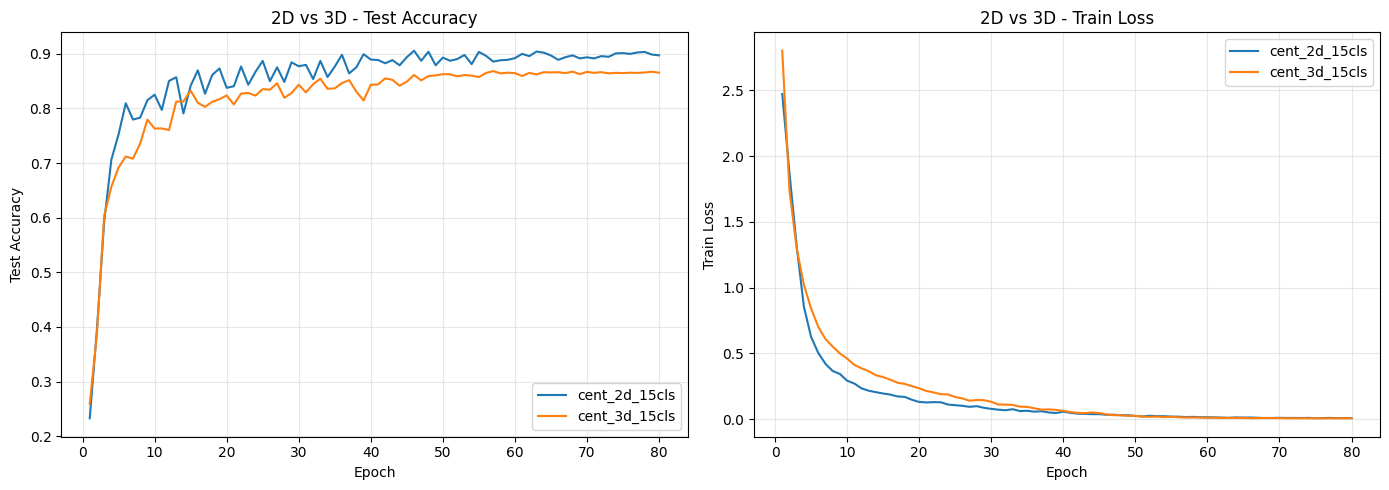

Saved: c:\Users\ESAI406_student1\Projects\RA\pyskl-research\demo1_fed_skeleton\outputs\cent_2d_vs_3d_curves.png


In [8]:
# ── Centralized comparison ──
import matplotlib.pyplot as plt

all_cent = {}
for tag in ['cent_2d_15cls', 'cent_3d_15cls']:
    path = OUTPUT_DIR / f'{tag}_results.json'
    if path.exists():
        all_cent[tag] = load_result(tag)
        r = all_cent[tag]
        print(f"{tag}: best={r['best_acc']:.4f} (ep {r['best_epoch']})  "
              f"final={r['final_acc']:.4f}  time={r['total_time_s']/60:.1f}min  "
              f"params={r['params']:,}")

# Learning curves
if len(all_cent) >= 2:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for tag, r in all_cent.items():
        eps = [h['epoch'] for h in r['history']]
        ax1.plot(eps, [h['test_acc'] for h in r['history']], label=tag)
        ax2.plot(eps, [h['train_loss'] for h in r['history']], label=tag)
    ax1.set(xlabel='Epoch', ylabel='Test Accuracy', title='2D vs 3D - Test Accuracy')
    ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.set(xlabel='Epoch', ylabel='Train Loss', title='2D vs 3D - Train Loss')
    ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'cent_2d_vs_3d_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUTPUT_DIR / 'cent_2d_vs_3d_curves.png'}")

In [9]:
# ── Per-class comparison table ──
if len(all_cent) >= 2:
    print(f"{'Class':2s}  {'Name':20s}  {'2D Acc':>7s}  {'3D Acc':>7s}  {'Delta':>7s}")
    print('-' * 60)
    r2 = all_cent['cent_2d_15cls']['per_class_acc']
    r3 = all_cent['cent_3d_15cls']['per_class_acc']
    for c in range(NUM_CLASSES):
        a2 = r2[str(c)]['accuracy'] if str(c) in r2 else 0
        a3 = r3[str(c)]['accuracy'] if str(c) in r3 else 0
        name = MEDICAL_LABELS[c]
        delta = a3 - a2
        marker = '+' if delta > 0 else ''
        print(f"[{c:2d}]  {name:20s}  {a2:.4f}   {a3:.4f}   {marker}{delta:.4f}")

Class  Name                   2D Acc   3D Acc    Delta
------------------------------------------------------------
[ 0]  falling               0.9709   0.9636   -0.0073
[ 1]  staggering            0.9819   0.9674   -0.0145
[ 2]  nausea/vomiting       0.7891   0.8145   +0.0254
[ 3]  touch head            0.8297   0.7899   -0.0398
[ 4]  touch chest           0.9746   0.9348   -0.0398
[ 5]  touch back            0.9783   0.8841   -0.0942
[ 6]  touch neck            0.8804   0.8116   -0.0688
[ 7]  sneeze/cough          0.7826   0.6667   -0.1159
[ 8]  standing up           0.9817   0.9597   -0.0220
[ 9]  sitting down          0.9890   0.9707   -0.0183
[10]  walking towards       0.9963   0.9451   -0.0512
[11]  walking apart         0.9674   0.9167   -0.0507
[12]  drinking              0.9526   0.8358   -0.1168
[13]  eating                0.8436   0.7673   -0.0763
[14]  phone call            0.6691   0.8000   +0.1309


---
## 4. Federated Learning — 3D (NTU-25) — FedAvg / FedBN / FedProx

Runs Flower simulation with 5 hospital clients (Dirichlet alpha=0.5 non-IID split).
**Priority:** 3D skeleton data to match reporting timeline.

In [5]:
# ── Federated training function ──
import flwr as fl
from flwr.common import ndarrays_to_parameters
from fl.client import SkeletonClient, _split_param_names
from fl.strategy_fsar import FSARStrategy


def evaluate_global(model, test_loader, device):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    loss_sum, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss_sum += criterion(logits, yb).item() * yb.size(0)
            preds = logits.argmax(1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(yb.cpu().tolist())
    return loss_sum / max(total, 1), correct / max(total, 1), all_preds, all_labels


def make_client_fn(data_dir, num_classes, device_str, local_bn,
                   epochs_per_round, lr, batch_size, mu, model_kwargs):
    def client_fn(context):
        if hasattr(context, 'node_config'):
            cid = str(context.node_config.get('partition-id', 0))
        else:
            cid = str(context)
        return SkeletonClient(
            cid=int(cid),
            data_path=data_dir / f'client_{cid}.npz',
            num_classes=num_classes, in_channels=3,
            device=device_str, local_bn=local_bn,
            epochs_per_round=epochs_per_round,
            lr=lr, batch_size=batch_size, mu=mu,
            model_kwargs=model_kwargs,
        ).to_client()
    return client_fn


def train_federated(tag, data_dir, mode, graph='coco', num_classes=15,
                    num_rounds=50, epochs_per_round=3, batch_size=64,
                    lr=0.01, mu=0.01):
    """Full federated training run. Returns results dict."""
    data_dir = Path(data_dir)
    client_files = sorted(data_dir.glob('client_*.npz'))
    num_clients = len(client_files)

    print(f"\n{'='*60}")
    print(f"  Starting FL: {tag}")
    print(f"  mode={mode}  rounds={num_rounds}  clients={num_clients}")
    print(f"  graph={graph}  epr={epochs_per_round}  lr={lr}  mu={mu}")
    print(f"{'='*60}\n")

    local_bn = mode in ('fedbn', 'cluster')
    actual_mu = mu if mode == 'fedprox' else 0.0
    model_kwargs = dict(base_channels=64, num_stages=6, num_person=2, graph=graph)

    ref_model = build_model(num_classes=num_classes, in_channels=3, **model_kwargs)
    print(f"Model params: {count_parameters(ref_model):,}")

    if local_bn:
        g_keys, l_keys = _split_param_names(ref_model)
        init_ndarrays = [ref_model.state_dict()[k].cpu().numpy() for k in g_keys]
    else:
        init_ndarrays = [v.cpu().numpy() for v in ref_model.state_dict().values()]

    strategy = FSARStrategy(
        mode=mode, initial_parameters=ndarrays_to_parameters(init_ndarrays),
        fraction_fit=1.0, fraction_evaluate=1.0,
        min_fit_clients=num_clients, min_evaluate_clients=num_clients,
        min_available_clients=num_clients)

    client_fn = make_client_fn(
        data_dir, num_classes, str(device), local_bn,
        epochs_per_round, lr, batch_size, actual_mu, model_kwargs)

    t_start = time.time()
    fl.simulation.start_simulation(
        client_fn=client_fn, num_clients=num_clients,
        config=fl.server.ServerConfig(num_rounds=num_rounds),
        strategy=strategy,
        client_resources={'num_cpus': 1, 'num_gpus': 0.0})
    total_time = time.time() - t_start

    # Load aggregated weights
    if strategy.last_aggregated_ndarrays is not None:
        sd = ref_model.state_dict()
        if local_bn:
            for k, v in zip(g_keys, strategy.last_aggregated_ndarrays):
                sd[k] = torch.tensor(v)
        else:
            for k, v in zip(sd.keys(), strategy.last_aggregated_ndarrays):
                sd[k] = torch.tensor(v)
        ref_model.load_state_dict(sd)

    # Global test
    test_path = data_dir / 'test.npz'
    test_loss, test_acc, preds, labels = None, None, [], []
    if test_path.exists():
        te = np.load(test_path)
        x_test = torch.from_numpy(te['x'].astype(np.float32))
        y_test = torch.from_numpy(te['y'].astype(np.int64))
        test_loader = DataLoader(TensorDataset(x_test, y_test), batch_size=batch_size)
        ref_model.to(device)
        test_loss, test_acc, preds, labels = evaluate_global(
            ref_model, test_loader, device)
        print(f"\nGlobal test: loss={test_loss:.4f}  acc={test_acc:.4f}")

    # Metrics
    per_class, cm = compute_metrics(preds, labels, num_classes) if preds else ({}, None)

    # Save
    torch.save(ref_model.state_dict(), OUTPUT_DIR / f'{tag}_global.pt')
    if cm is not None:
        save_confusion_csv(cm, MEDICAL_LABELS[:num_classes],
                           OUTPUT_DIR / f'{tag}_confusion_matrix.csv')

    result = {
        'tag': tag, 'mode': mode, 'graph': graph,
        'num_classes': num_classes, 'num_clients': num_clients,
        'num_rounds': num_rounds, 'epochs_per_round': epochs_per_round,
        'batch_size': batch_size, 'lr': lr, 'mu': actual_mu,
        'params': count_parameters(ref_model),
        'final_test_acc': round(test_acc, 4) if test_acc else None,
        'final_test_loss': round(test_loss, 4) if test_loss else None,
        'total_time_s': round(total_time, 1),
        'label_names': MEDICAL_LABELS[:num_classes],
        'per_class_acc': {int(k): v for k, v in per_class.items()},
        'confusion_matrix': cm.tolist() if cm is not None else None,
        'round_history': strategy.history,
    }
    with open(OUTPUT_DIR / f'{tag}_results.json', 'w') as f:
        json.dump(result, f, indent=2)

    print(f"\n{'='*60}")
    print(f"  {tag} COMPLETE")
    if strategy.history:
        last = strategy.history[-1]
        print(f"  Last round: global_acc={last.get('global_acc', 0):.4f}  "
              f"worst={last.get('worst_client_acc', 0):.4f}")
    if test_acc:
        print(f"  Global test acc: {test_acc:.4f}")
    print(f"  Time: {total_time/60:.1f} min")
    print(f"{'='*60}")
    if per_class:
        print_per_class(per_class)

    return result

print("train_federated() ready.")

train_federated() ready.


### 4a. FedAvg 3D Baseline

In [ ]:
%%time
results_fedavg_3d = train_federated(
    tag='fl_fedavg_3d_15cls',
    data_dir=DEMO_DIR / 'data/fed_medical_3d',
    mode='fedavg',
    graph='ntu',
    num_rounds=50,
    epochs_per_round=3,
    batch_size=64,
    lr=0.01,
)

c:\Users\ESAI406_student1\Projects\RA\pyskl-research\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-19 01:32:01,947	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=50, no round_timeout



  Starting FL: fl_fedavg_3d_15cls
  mode=fedavg  rounds=50  clients=5
  graph=ntu  epr=3  lr=0.01  mu=0.01

Model params: 450,603


2026-04-19 01:32:02,663	ERROR services.py:1360 -- Failed to start the dashboard , return code 1
2026-04-19 01:32:02,663	ERROR services.py:1385 -- Error should be written to 'dashboard.log' or 'dashboard.err'. We are printing the last 20 lines for you. See 'https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#logging-directory-structure' to find where the log file is.
2026-04-19 01:32:02,663	ERROR services.py:1395 -- Couldn't read dashboard.log file. Error: [Errno 2] No such file or directory: 'C:\\Users\\ESAI40~1\\AppData\\Local\\Temp\\ray\\session_2026-04-19_01-32-02_001750_18812\\logs\\dashboard.log'. It means the dashboard is broken even before it initializes the logger (mostly dependency issues). Reading the dashboard.err file which contains stdout/stderr.
2026-04-19 01:32:02,663	ERROR services.py:1429 -- Failed to read dashboard.err file: [Errno 2] No such file or directory: 'C:\\Users\\ESAI40~1\\AppData\\Local\\Temp\\ray\\session_2026-04-19_01-32-02_

### 4b. FedBN 3D (BatchNorm local)

In [ ]:
%%time
results_fedbn_3d = train_federated(
    tag='fl_fedbn_3d_15cls',
    data_dir=DEMO_DIR / 'data/fed_medical_3d',
    mode='fedbn',
    graph='ntu',
    num_rounds=50,
    epochs_per_round=3,
    batch_size=64,
    lr=0.01,
)

### 4c. FedProx 3D (mu=0.01)

In [ ]:
%%time
results_fedprox_3d = train_federated(
    tag='fl_fedprox_mu0.01_3d_15cls',
    data_dir=DEMO_DIR / 'data/fed_medical_3d',
    mode='fedprox',
    graph='ntu',
    num_rounds=50,
    epochs_per_round=3,
    batch_size=64,
    lr=0.01,
    mu=0.01,
)

### 4d. FedProx 3D (mu=0.001 — lighter regularization)

In [ ]:
%%time
results_fedprox_lo_3d = train_federated(
    tag='fl_fedprox_mu0.001_3d_15cls',
    data_dir=DEMO_DIR / 'data/fed_medical_3d',
    mode='fedprox',
    graph='ntu',
    num_rounds=50,
    epochs_per_round=3,
    batch_size=64,
    lr=0.01,
    mu=0.001,
)

---
## 5. FL Comparison — All Methods

In [ ]:
# ── Load all FL results ──
import matplotlib.pyplot as plt

fl_tags = [
    'fl_fedavg_3d_15cls',
    'fl_fedbn_3d_15cls',
    'fl_fedprox_mu0.01_3d_15cls',
    'fl_fedprox_mu0.001_3d_15cls',
]
fl_results = {}
for tag in fl_tags:
    path = OUTPUT_DIR / f'{tag}_results.json'
    if path.exists():
        fl_results[tag] = load_result(tag)

# Summary table
print(f"{'Tag':40s}  {'Test Acc':>8s}  {'Time':>6s}  {'Rounds':>6s}")
print('-' * 68)
for tag, r in fl_results.items():
    acc = r.get('final_test_acc', 0) or 0
    t = r.get('total_time_s', 0) / 60
    rnd = r.get('num_rounds', 0)
    print(f"{tag:40s}  {acc:8.4f}  {t:5.1f}m  {rnd:6d}")

# Include centralized for context
for tag in ['cent_2d_15cls', 'cent_3d_15cls']:
    path = OUTPUT_DIR / f'{tag}_results.json'
    if path.exists():
        r = load_result(tag)
        print(f"{tag + ' (centralized)':40s}  {r['best_acc']:8.4f}  "
              f"{r['total_time_s']/60:5.1f}m  {'N/A':>6s}")

In [ ]:
# ── FL convergence curves ──
if fl_results:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for tag, r in fl_results.items():
        hist = r.get('round_history', [])
        if hist:
            rounds = [h['round'] for h in hist]
            short = tag.replace('_3d_15cls', '').replace('fl_', '')
            ax1.plot(rounds, [h.get('global_acc', 0) for h in hist], label=short)
            ax2.plot(rounds, [h.get('worst_client_acc', 0) for h in hist], label=short)
    ax1.set(xlabel='Round', ylabel='Global Accuracy', title='FL Methods 3D - Global Accuracy')
    ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.set(xlabel='Round', ylabel='Worst Client Acc', title='FL Methods 3D - Worst Client')
    ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fl_3d_methods_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUTPUT_DIR / 'fl_3d_methods_comparison.png'}")

---
## 6. Confusion Matrix Heatmaps

In [ ]:
import matplotlib.pyplot as plt

def plot_confusion(tag, title=None):
    path = OUTPUT_DIR / f'{tag}_results.json'
    if not path.exists():
        print(f"No results for {tag}")
        return
    r = load_result(tag)
    cm = np.array(r['confusion_matrix'])
    labels = r.get('label_names', MEDICAL_LABELS[:cm.shape[0]])

    # Normalize by row (true class)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(1)

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title or f'Confusion Matrix: {tag}')

    # Annotate cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if cm[i, j] > 0:
                color = 'white' if cm_norm[i, j] > 0.5 else 'black'
                ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                        fontsize=7, color=color)

    plt.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    out = OUTPUT_DIR / f'{tag}_confusion_heatmap.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {out}")

# Plot for all available experiments
for tag in ['cent_2d_15cls', 'cent_3d_15cls',
            'fl_fedavg_3d_15cls', 'fl_fedbn_3d_15cls',
            'fl_fedprox_mu0.01_3d_15cls']:
    if (OUTPUT_DIR / f'{tag}_results.json').exists():
        plot_confusion(tag)

---
## 7. Export to Experiment Log

In [ ]:
# ── Append results to experiments/log.md ──
log_path = ROOT / 'experiments' / 'log.md'
timestamp = datetime.now().strftime('%Y-%m-%d %H:%M')

# Gather all results
all_tags = ['cent_2d_15cls', 'cent_3d_15cls',
            'fl_fedavg_3d_15cls', 'fl_fedbn_3d_15cls',
            'fl_fedprox_mu0.01_3d_15cls', 'fl_fedprox_mu0.001_3d_15cls']

entry_lines = []
entry_lines.append(f"\n\n## 15-Class Medical HAR — Local RTX 5090 — {timestamp}\n")
entry_lines.append(f"\n**Machine:** RTX 5090, PyTorch {torch.__version__}, Python {sys.version.split()[0]}\n")
entry_lines.append(f"**Data:** NTU RGB+D 60 filtered to 15 medical classes, train=10032 test=4125\n")
entry_lines.append(f"**Model:** STGCN++ (6-stage, base_ch=64, dropout=0.3)\n")

entry_lines.append(f"\n### Results Summary\n")
entry_lines.append(f"| Experiment | Accuracy | Params | Time | Notes |\n")
entry_lines.append(f"|------------|----------|--------|------|-------|\n")

for tag in all_tags:
    path = OUTPUT_DIR / f'{tag}_results.json'
    if not path.exists():
        continue
    r = load_result(tag)
    if 'best_acc' in r:  # centralized
        acc = f"{r['best_acc']:.4f}"
        notes = f"best@ep{r.get('best_epoch','?')}, {r.get('epochs','?')} epochs"
    else:  # federated
        acc = f"{r.get('final_test_acc', 0):.4f}"
        notes = f"{r.get('mode','?')}, {r.get('num_rounds','?')}R x {r.get('epochs_per_round','?')}E"
        if r.get('mu', 0) > 0:
            notes += f", mu={r['mu']}"
    t_min = r.get('total_time_s', 0) / 60
    params = f"{r.get('params', 0):,}"
    entry_lines.append(f"| {tag} | {acc} | {params} | {t_min:.1f}m | {notes} |\n")

entry_text = ''.join(entry_lines)
print(entry_text)

# Append to log
with open(log_path, 'a', encoding='utf-8') as f:
    f.write(entry_text)
print(f"\nAppended to {log_path}")

---
## 8. Output Artifacts Summary

In [ ]:
# ── List all artifacts ──
print(f"Output directory: {OUTPUT_DIR}\n")
artifacts = sorted(OUTPUT_DIR.iterdir())
for f in artifacts:
    size = f.stat().st_size
    if size > 1024*1024:
        size_str = f"{size/1024/1024:.1f} MB"
    elif size > 1024:
        size_str = f"{size/1024:.1f} KB"
    else:
        size_str = f"{size} B"
    print(f"  {f.name:50s}  {size_str:>10s}")